# E3 (`e3_new_training_data`) — Results

Unified analysis notebook for the E3 experiment (`outputs/e3_new_training_data/`).

**Sections:**
1. **Transferability & permutation equivariance** — betty rerun of the April study, plus a betty-vs-lambda A/B comparison.
2. **E3 models on E4 test graphs** — cross-eval of the e3 checkpoints against the larger e4 v4 test graphs.

| Label | Run ID | Description |
|-------|--------|-------------|
| **BASELINE** | `0sy9j5rz` | LLM-only |
| **GT** | `bzqt4zxt` | RPEARL-GT (ground-truth graph), no edges in text |
| **RPEARL** | `qmu8x2qu` | RPEARL (predicted graph), no edges in text |

Sources merged: `e3_transferability_betty_results.ipynb` + `e3_on_e4_eval_results.ipynb`. Per-epoch training-eval (from the original `e3_transferability_results.ipynb`) is intentionally not carried over — it's orthogonal to these analyses.


In [1]:
import json
import os
import glob
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# ── Config ────────────────────────────────────────────────────────────
E3_DIR        = "../outputs/e3_new_training_data"
TRANSFER_DIR  = "../results/e3_transferability_betty"   # betty rerun
TRANSFER_DIR_APRIL = "../results"                        # original April run, for A/B
DATA_DIR      = "../data/eval/transferability_data_v1"
SEED_DIRS     = ["perm_32", "perm_42", "perm_58"]
GRAPH_SIZES   = [10, 30, 50, 100, 250, 500, 1000]

# Map run-id suffix → condition label
RUN_TO_CONDITION = {
    "0sy9j5rz": "BASELINE",
    "bzqt4zxt": "GT",
    "qmu8x2qu": "RPEARL",
}

CONDITION_COLORS = {
    "BASELINE": "#2196F3",
    "GT":       "#4CAF50",
    "RPEARL":   "#FF9800",
}


# Dataset — `eval_graph_unique_{N}.json`

Eval files in `data/eval/transferability_data_v1/`. Each file is **one** scene graph plus 10 hand-written tasks. The graph has two node types — `objects` and `regions` — and two edge types:

- `object_connections`: object → region (which region holds each object)
- `region_connections`: region ↔ region adjacency

The filename suffix `N` is the *unique-objects* tier; the actual node count grows roughly with `N` but **edges grow super-linearly** because region adjacency densifies fast. This matters for context size: at `N=1000` the prompt encodes ~35k edges, which is what eventually OOMs the 24 GB GPU at the largest tier.

In [2]:
data_records = []
for size in GRAPH_SIZES:
    fp = os.path.join(DATA_DIR, f"eval_graph_unique_{size}.json")
    if not os.path.exists(fp):
        print(f"WARN: missing {fp}")
        continue
    with open(fp) as f:
        d = json.load(f)
    g = d["graph"]
    n_obj = len(g.get("objects", []))
    n_reg = len(g.get("regions", []))
    n_oc  = len(g.get("object_connections", []))
    n_rc  = len(g.get("region_connections", []))
    data_records.append({
        "graph_size":  size,
        "objects":     n_obj,
        "regions":     n_reg,
        "total_nodes": n_obj + n_reg,
        "object_conn": n_oc,
        "region_conn": n_rc,
        "total_edges": n_oc + n_rc,
        "tasks":       len(d["tasks"]),
    })

df_data = pd.DataFrame(data_records).set_index("graph_size")
df_data.style.format("{:,}")

,objects,regions,total_nodes,object_conn,region_conn,total_edges,tasks
graph_size,,,,,,,
10,4,8,12,4,10,14,10
30,4,24,28,4,62,66,10
50,6,40,46,6,128,134,10
100,27,75,102,27,440,467,10
250,62,192,254,62,"2,567","2,629",10
500,133,385,518,133,"9,539","9,672",10
1000,222,768,990,222,"34,931","35,153",10


## Estimated prompt-token budget per task

Rough back-of-the-envelope estimate of how many input tokens the LLM sees per task as the graph grows. Heuristic:

1. Serialize the full graph to compact JSON → `graph_chars`
2. Add the task text → `avg_prompt_chars`
3. Divide by **4 chars/token** (rule-of-thumb for English/structured text)

This **ignores** the system prompt, examples, and any agent-specific scaffolding, and assumes the entire graph is shoved into context (worst case for the LLM-only baseline; the RPEARL conditions encode the graph as embeddings, so their textual prompt is much smaller). Treat as an upper bound for the text-only path.

In [4]:
CHARS_PER_TOKEN = 4  # rough heuristic for English / structured text

token_records = []
for size in GRAPH_SIZES:
    fp = os.path.join(DATA_DIR, f"eval_graph_unique_{size}.json")
    if not os.path.exists(fp):
        continue
    with open(fp) as f:
        d = json.load(f)

    # Per-task prompt ≈ full-graph context (json-serialized) + task text
    graph_chars = len(json.dumps(d["graph"]))
    task_chars = [
        len(t["task"]) if isinstance(t, dict) else len(str(t))
        for t in d["tasks"]
    ]
    avg_task_chars = sum(task_chars) / len(task_chars)
    avg_prompt_chars = graph_chars + avg_task_chars

    token_records.append({
        "graph_size":       size,
        "graph_chars":      graph_chars,
        "avg_task_chars":   round(avg_task_chars, 1),
        "avg_prompt_chars": round(avg_prompt_chars, 1),
        "est_tokens":       int(round(avg_prompt_chars / CHARS_PER_TOKEN)),
    })

df_tokens = pd.DataFrame(token_records).set_index("graph_size")
df_tokens.style.format({
    "graph_chars":      "{:,}",
    "avg_task_chars":   "{:,.1f}",
    "avg_prompt_chars": "{:,.1f}",
    "est_tokens":       "{:,}",
})

,graph_chars,avg_task_chars,avg_prompt_chars,est_tokens
graph_size,,,,
10,"1,293",48.7,"1,341.7",335
30,"3,935",58.4,"3,993.4",998
50,"8,400",54.0,"8,454.0","2,114"
100,"19,988",42.3,"20,030.3","5,008"
250,"113,378",51.1,"113,429.1","28,357"
500,"375,446",50.1,"375,496.1","93,874"
1000,"1,411,397",49.0,"1,411,446.0","352,862"


# Transferability & Permutation Equivariance — Across Graph Sizes

Final-checkpoint eval results from `results/perm_{32,42,58}/`. Each run was evaluated on `eval_graph_unique_{10,30,50,100,250,500,1000}.json` under three node-permutation seeds (32, 42, 58).

- **Transferability:** mean accuracy across seeds vs. graph size — does the policy still work as the scene grows?
- **Permutation equivariance:** spread across seeds at the same graph size — should be near-zero for an equivariant model.

| Label | Run ID | Description |
|-------|--------|-------------|
| **BASELINE** | `0sy9j5rz` | LLM-only |
| **GT** | `bzqt4zxt` | RPEARL-GT (ground-truth graph) |
| **RPEARL** | `qmu8x2qu` | RPEARL (predicted graph) |

In [5]:
def load_trans_records(transfer_dir):
    """Glob per-trial JSONs under <transfer_dir>/perm_*/<run_id>_*_eval_graph_unique_*.json.

    Robust to missing summary files (LLM × perm_32 crashed mid-sweep on betty).
    Returns a long-form DataFrame with one row per (run_id, seed, graph_size).
    """
    records = []
    for seed_dir in SEED_DIRS:
        seed = int(seed_dir.split("_")[1])
        for run_id, condition in RUN_TO_CONDITION.items():
            pattern = os.path.join(
                transfer_dir, seed_dir,
                f"*{run_id}_eval_graph_unique_*.json",
            )
            paths = sorted(glob.glob(pattern))
            if not paths:
                print(f"WARN: no trial files for {run_id} in {seed_dir} ({transfer_dir})")
                continue
            for path in paths:
                # Skip the per-run summary if globbed by accident
                if path.endswith("_summary.json"):
                    continue
                m = re.search(r"eval_graph_unique_(\d+)\.json", path)
                if not m:
                    continue
                with open(path) as f:
                    trial = json.load(f)
                records.append({
                    "run_id":      run_id,
                    "condition":   condition,
                    "seed":        seed,
                    "graph_size":  int(m.group(1)),
                    "accuracy":    trial["accuracy"],
                    "num_correct": trial["num_correct"],
                    "num_total":   trial["num_total"],
                    "num_errors":  trial.get("num_errors", 0),
                })
    return (
        pd.DataFrame(records)
        .sort_values(["condition", "seed", "graph_size"])
        .reset_index(drop=True)
    )


df_trans = load_trans_records(TRANSFER_DIR)
print(
    f"Loaded {len(df_trans)} trials | "
    f"{df_trans.seed.nunique()} seeds × "
    f"{df_trans.condition.nunique()} conditions × "
    f"{df_trans.graph_size.nunique()} graph sizes"
)

# Coverage check — flag any (condition, seed, size) cells that didn't run
expected = {(c, s, g) for c in RUN_TO_CONDITION.values()
            for s in [32, 42, 58] for g in GRAPH_SIZES}
got = set(zip(df_trans.condition, df_trans.seed, df_trans.graph_size))
missing = sorted(expected - got)
if missing:
    print(f"\nMissing {len(missing)} cells (likely OOM): {missing}")
df_trans.head(15)


Loaded 58 trials | 3 seeds × 3 conditions × 7 graph sizes

Missing 5 cells (likely OOM): [('BASELINE', 32, 30), ('BASELINE', 32, 50), ('BASELINE', 32, 250), ('BASELINE', 32, 500), ('BASELINE', 32, 1000)]


,run_id,condition,seed,graph_size,accuracy,num_correct,num_total,num_errors
0,0sy9j5rz,BASELINE,32,10,0.9,9,10,0
1,0sy9j5rz,BASELINE,32,100,0.1,1,10,0
2,0sy9j5rz,BASELINE,42,10,0.9,9,10,0
3,0sy9j5rz,BASELINE,42,30,0.8,8,10,0
4,0sy9j5rz,BASELINE,42,50,0.0,0,10,0
5,0sy9j5rz,BASELINE,42,100,0.9,9,10,0
6,0sy9j5rz,BASELINE,42,250,0.6,6,10,0
7,0sy9j5rz,BASELINE,42,500,0.0,0,10,0
8,0sy9j5rz,BASELINE,42,1000,0.0,0,10,10
9,0sy9j5rz,BASELINE,58,10,0.9,9,10,0


### Plot — Accuracy vs Graph Size (transferability)

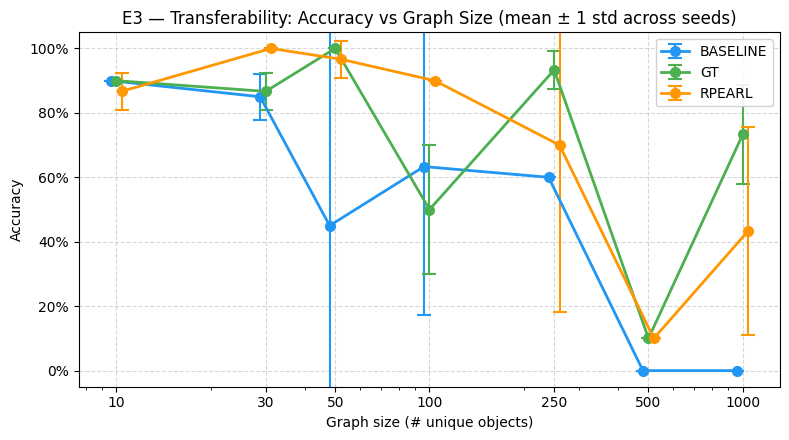

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# Small horizontal jitter so error bars don't overlap on the log axis
JITTER = {"BASELINE": 0.96, "GT": 1.00, "RPEARL": 1.04}

for condition in ["BASELINE", "GT", "RPEARL"]:
    sub = agg_trans[agg_trans["condition"] == condition].sort_values("graph_size")
    color = CONDITION_COLORS[condition]
    x = sub["graph_size"] * JITTER[condition]
    ax.errorbar(
        x, sub["mean"], yerr=sub["std"],
        marker="o", color=color, label=condition,
        linewidth=2, markersize=7,
        elinewidth=1.5, capsize=5, capthick=1.5,
    )

ax.set_xscale("log")
ax.set_xticks(GRAPH_SIZES)
ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
ax.set_xlabel("Graph size (# unique objects)")
ax.set_ylabel("Accuracy")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(-0.05, 1.05)
ax.set_title("E3 — Transferability: Accuracy vs Graph Size (mean ± 1 std across seeds)")
ax.legend(loc="upper right", framealpha=0.9)
ax.grid(axis="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Plot — Per-Seed Accuracy (permutation equivariance)

Three seeds overlaid per condition. Tight bunching across seeds = closer to permutation-equivariant on this task.

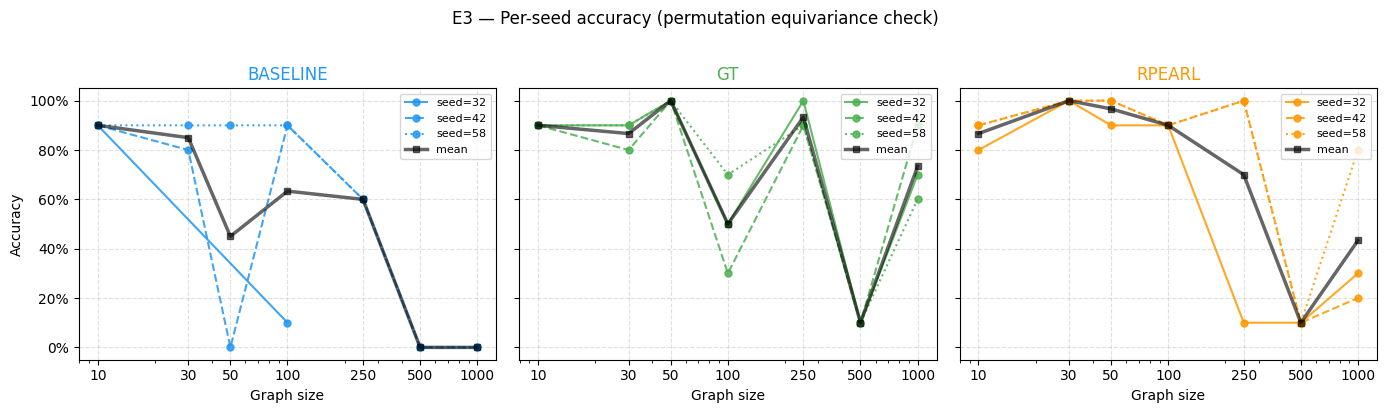

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

seed_styles = {32: "-", 42: "--", 58: ":"}

for ax, condition in zip(axes, ["BASELINE", "GT", "RPEARL"]):
    color = CONDITION_COLORS[condition]
    sub_cond = df_trans[df_trans["condition"] == condition]
    for seed, group in sub_cond.groupby("seed"):
        g = group.sort_values("graph_size")
        ax.plot(
            g["graph_size"], g["accuracy"],
            marker="o", color=color, linestyle=seed_styles.get(seed, "-"),
            label=f"seed={seed}", linewidth=1.5, markersize=5, alpha=0.85,
        )
    # Mean across seeds (heavier black line)
    mean_sub = agg_trans[agg_trans["condition"] == condition].sort_values("graph_size")
    ax.plot(
        mean_sub["graph_size"], mean_sub["mean"],
        marker="s", color="black", linewidth=2.5, markersize=4, alpha=0.6, label="mean",
    )

    ax.set_xscale("log")
    ax.set_xticks(GRAPH_SIZES)
    ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
    ax.set_xlabel("Graph size")
    ax.set_title(condition, color=color)
    ax.set_ylim(-0.05, 1.05)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.grid(axis="both", linestyle="--", alpha=0.4)
    ax.legend(fontsize=8, loc="upper right")

axes[0].set_ylabel("Accuracy")
fig.suptitle("E3 — Per-seed accuracy (permutation equivariance check)", y=1.02)
plt.tight_layout()
plt.show()

### Summary table — accuracy (mean ± std across seeds) per graph size

In [9]:
def _fmt(row):
    if row["n"] > 1:
        return f"{row['mean']*100:.0f}% ± {row['std']*100:.0f}%"
    return f"{row['mean']*100:.0f}%"

agg_trans["display"] = agg_trans.apply(_fmt, axis=1)
pivot = (
    agg_trans
    .pivot(index="condition", columns="graph_size", values="display")
    .reindex(index=["BASELINE", "GT", "RPEARL"], columns=GRAPH_SIZES)
)
pivot

graph_size,10,30,50,100,250,500,1000
condition,,,,,,,
BASELINE,90% ± 0%,85% ± 7%,45% ± 64%,63% ± 46%,60% ± 0%,0% ± 0%,0% ± 0%
GT,90% ± 0%,87% ± 6%,100% ± 0%,50% ± 20%,93% ± 6%,10% ± 0%,73% ± 15%
RPEARL,87% ± 6%,100% ± 0%,97% ± 6%,90% ± 0%,70% ± 52%,10% ± 0%,43% ± 32%


### LaTeX table

In [10]:
latex_pivot = pivot.copy()
latex_pivot.index.name = "Condition"
latex_pivot.columns.name = "Graph size"
print(latex_pivot.to_latex(
    caption="E3 Transferability --- Accuracy vs Graph Size (mean $\\pm$ std over 3 seeds)",
    label="tab:e3_transfer_by_size",
    escape=False,
))

\begin{table}
\caption{E3 Transferability --- Accuracy vs Graph Size (mean $\pm$ std over 3 seeds)}
\label{tab:e3_transfer_by_size}
\begin{tabular}{llllllll}
\toprule
Graph size & 10 & 30 & 50 & 100 & 250 & 500 & 1000 \\
Condition &  &  &  &  &  &  &  \\
\midrule
BASELINE & 90% ± 0% & 85% ± 7% & 45% ± 64% & 63% ± 46% & 60% ± 0% & 0% ± 0% & 0% ± 0% \\
GT & 90% ± 0% & 87% ± 6% & 100% ± 0% & 50% ± 20% & 93% ± 6% & 10% ± 0% & 73% ± 15% \\
RPEARL & 87% ± 6% & 100% ± 0% & 97% ± 6% & 90% ± 0% & 70% ± 52% & 10% ± 0% & 43% ± 32% \\
\bottomrule
\end{tabular}
\end{table}



## Failure-mode breakdown per condition

Per-sample outcomes from each `*_eval_graph_unique_*.json`. Each sample carries a `terminated_by` field plus `error` / `correct`. Outcomes are categorised as:

- **correct** — the model gave a correct answer
- **answer** — model produced an answer but it was wrong (semantic / retrieval failure)
- **bad_plan** — planner returned an invalid / unparseable plan
- **max_iterations** — agent loop hit its action-step cap (not the LLM's token cap)
- **OOM** — `terminated_by="exception"` whose error string is a CUDA out-of-memory (prompt no longer fits in GPU memory)
- **exception** — any other exception (none in current logs)

> Note: no failures match `max_new_tokens` / context-window-truncation patterns. The graph-size cliff at the largest sizes is dominated by CUDA OOM on the prompt, not by the LLM's context window.

In [11]:
fail_records = []
for seed_dir in SEED_DIRS:
    seed = int(seed_dir.split("_")[1])
    for run_id, condition in RUN_TO_CONDITION.items():
        for size in GRAPH_SIZES:
            pattern = os.path.join(
                TRANSFER_DIR, seed_dir,
                f"*{run_id}_eval_graph_unique_{size}.json",
            )
            matches = glob.glob(pattern)
            if not matches:
                continue   # missing cell (OOM); silently skip
            with open(matches[0]) as f:
                d = json.load(f)
            for s in d.get("samples", []):
                term = s.get("terminated_by")
                err = s.get("error") or ""
                if term == "exception":
                    if "out of memory" in err.lower() or "OutOfMemoryError" in err:
                        outcome = "OOM"
                    else:
                        outcome = "exception"
                elif s.get("correct"):
                    outcome = "correct"
                else:
                    outcome = term  # "answer" (wrong), "bad_plan", "max_iterations"

                fail_records.append({
                    "run_id":        run_id,
                    "condition":     condition,
                    "seed":          seed,
                    "graph_size":    size,
                    "terminated_by": term,
                    "correct":       bool(s.get("correct")),
                    "outcome":       outcome,
                })

df_fail = pd.DataFrame(fail_records)
print(f"Loaded {len(df_fail)} samples")
print("\nOverall outcome counts:")
print(df_fail["outcome"].value_counts())
print("\nPer condition:")
print(df_fail.groupby(["condition", "outcome"]).size().unstack(fill_value=0))


Loaded 580 samples

Overall outcome counts:
outcome
correct           384
answer             93
bad_plan           63
max_iterations     20
OOM                20
Name: count, dtype: int64

Per condition:
outcome    OOM  answer  bad_plan  correct  max_iterations
condition                                                
BASELINE    20       9        27       84              20
GT           0      42        17      151               0
RPEARL       0      42        19      149               0


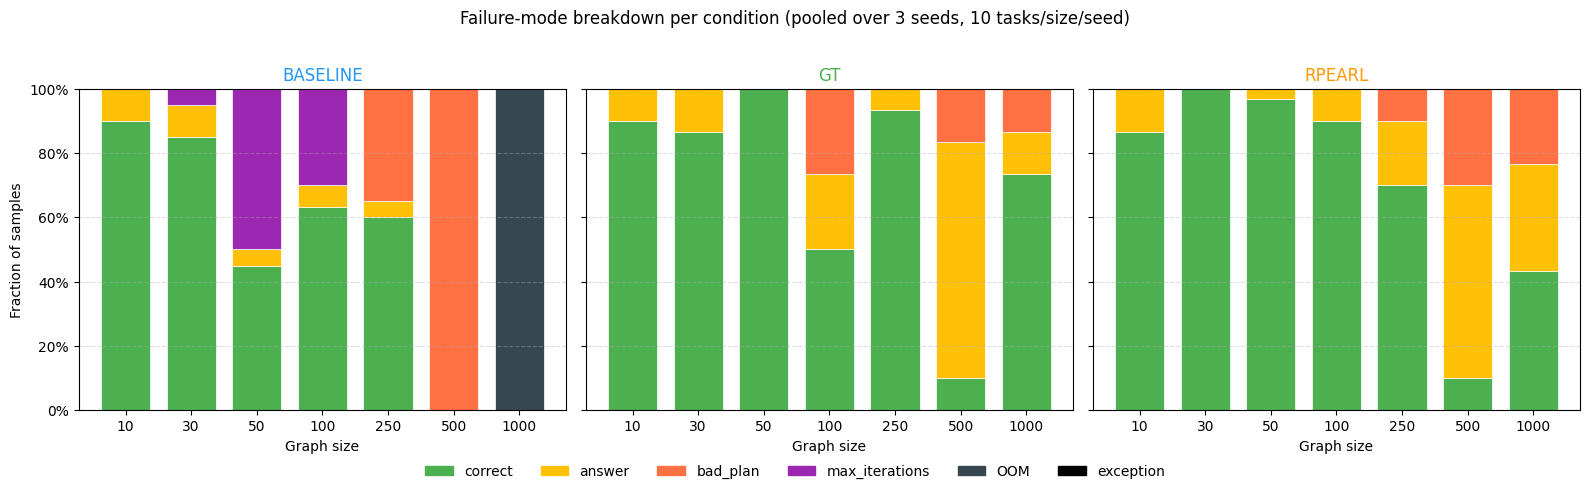

In [12]:
OUTCOME_ORDER = ["correct", "answer", "bad_plan", "max_iterations", "OOM", "exception"]
OUTCOME_COLORS = {
    "correct":        "#4CAF50",
    "answer":         "#FFC107",  # answered but wrong
    "bad_plan":       "#FF7043",
    "max_iterations": "#9C27B0",
    "OOM":            "#37474F",
    "exception":      "#000000",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, condition in zip(axes, ["BASELINE", "GT", "RPEARL"]):
    sub = df_fail[df_fail["condition"] == condition]
    counts = (
        sub.groupby(["graph_size", "outcome"]).size().unstack(fill_value=0)
        .reindex(index=GRAPH_SIZES, fill_value=0)
    )
    fracs = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    cols_present = [c for c in OUTCOME_ORDER if c in fracs.columns]
    fracs = fracs.reindex(columns=cols_present, fill_value=0)

    x = np.arange(len(fracs.index))
    bottom = np.zeros(len(fracs.index))
    for outcome in fracs.columns:
        ax.bar(
            x, fracs[outcome].values, bottom=bottom,
            color=OUTCOME_COLORS[outcome], label=outcome,
            edgecolor="white", linewidth=0.5, width=0.75,
        )
        bottom += fracs[outcome].values

    ax.set_xticks(x)
    ax.set_xticklabels(fracs.index)
    ax.set_xlabel("Graph size")
    ax.set_title(condition, color=CONDITION_COLORS[condition])
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.grid(axis="y", linestyle="--", alpha=0.4)

axes[0].set_ylabel("Fraction of samples")

# Single shared legend, ordered consistently
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=OUTCOME_COLORS[o]) for o in OUTCOME_ORDER
]
fig.legend(
    legend_handles, OUTCOME_ORDER,
    loc="lower center", ncol=len(OUTCOME_ORDER),
    bbox_to_anchor=(0.5, -0.05), frameon=False,
)
fig.suptitle("Failure-mode breakdown per condition (pooled over 3 seeds, 10 tasks/size/seed)", y=1.02)
plt.tight_layout()
plt.show()

## Comparing runs on betty (B200) vs lambda (RTX 3090)

Same script, same data, same flags — only the hardware (and the `--output` dir) differ. A gap here isolates GPU/memory effects from methodology drift.

April results live at `../results/perm_*/`. The April run also had partial cells at the largest sizes (workstation 24 GB OOM at N=1000), so expect some missing data on the April side too.


In [13]:
df_april = load_trans_records(TRANSFER_DIR_APRIL)
df_april["run"] = "april"
df_betty = df_trans.assign(run="betty")
df_ab = pd.concat([df_april, df_betty], ignore_index=True)

ab_agg = (
    df_ab.groupby(["run", "condition", "graph_size"])["accuracy"]
    .agg(mean="mean", n="count")
    .reset_index()
)
print(ab_agg.to_string(index=False))


  run condition  graph_size     mean  n
april  BASELINE          10 0.900000  3
april  BASELINE          30 0.900000  3
april  BASELINE          50 0.833333  3
april  BASELINE         100 0.400000  3
april  BASELINE         250 0.000000  3
april  BASELINE         500 0.000000  3
april  BASELINE        1000 0.000000  3
april        GT          10 0.900000  3
april        GT          30 0.966667  3
april        GT          50 1.000000  3
april        GT         100 0.766667  3
april        GT         250 0.533333  3
april        GT         500 0.400000  3
april        GT        1000 0.533333  3
april    RPEARL          10 0.833333  3
april    RPEARL          30 0.966667  3
april    RPEARL          50 0.866667  3
april    RPEARL         100 0.900000  3
april    RPEARL         250 0.633333  3
april    RPEARL         500 0.133333  3
april    RPEARL        1000 0.633333  3
betty  BASELINE          10 0.900000  3
betty  BASELINE          30 0.850000  2
betty  BASELINE          50 0.450000  2


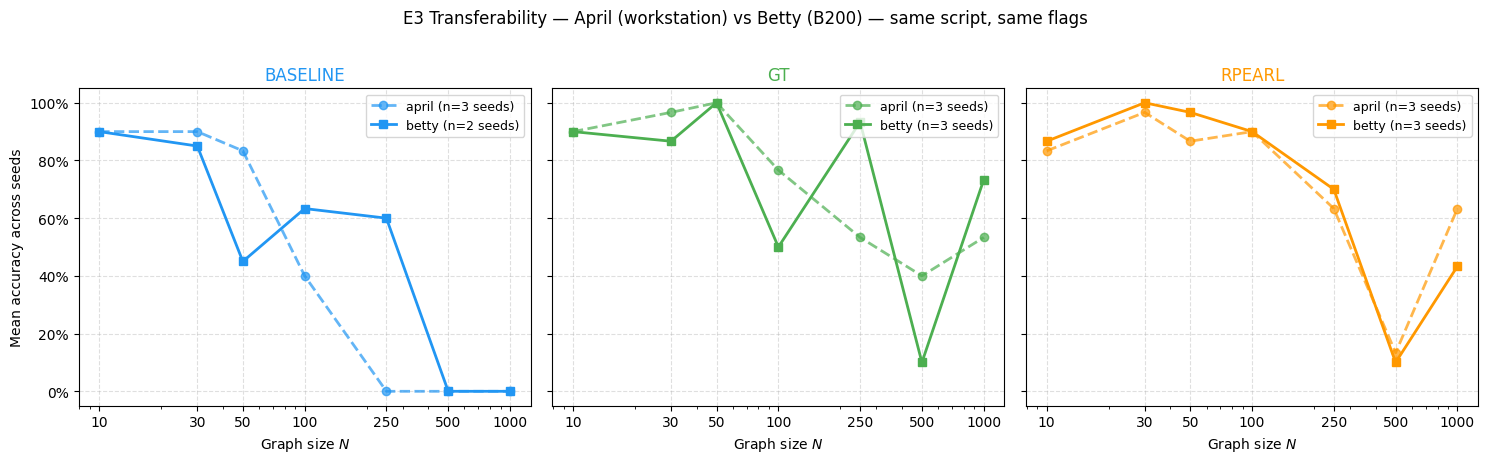

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, condition in zip(axes, ["BASELINE", "GT", "RPEARL"]):
    for run, marker, ls in [("april", "o", "--"), ("betty", "s", "-")]:
        sub = (
            ab_agg[(ab_agg["condition"] == condition) & (ab_agg["run"] == run)]
            .sort_values("graph_size")
        )
        if sub.empty:
            continue
        ax.plot(
            sub["graph_size"], sub["mean"],
            marker=marker, linestyle=ls, linewidth=2,
            color=CONDITION_COLORS[condition], alpha=0.7 if run == "april" else 1.0,
            label=f"{run} (n={int(sub['n'].mean())} seeds)",
        )
    ax.set_xscale("log")
    ax.set_xticks(GRAPH_SIZES)
    ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
    ax.set_xlabel("Graph size $N$")
    ax.set_title(condition, color=CONDITION_COLORS[condition])
    ax.set_ylim(-0.05, 1.05)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.grid(linestyle="--", alpha=0.4)
    ax.legend(loc="upper right", fontsize=9)

axes[0].set_ylabel("Mean accuracy across seeds")
fig.suptitle("E3 Transferability — April (workstation) vs Betty (B200) — same script, same flags", y=1.02)
plt.tight_layout()
plt.show()


# E3 Models on E4 Test Graphs

Transferability eval: e3-trained models (Llama-3.1-8B, trained on e3 data, smaller graphs)
evaluated against the larger e4 test graphs.

**Models evaluated:**
- `e3_llm` — plain LLM LoRA, `text_edge_list=present` (9 graphs, 90 tasks)
- `e3_rpearl` — graph-augmented (RPEARL), `text_edge_list=none` (5 graphs, 50 tasks — run was interrupted)

Results written by `scripts/eval_checkpoint_on_graphs.py` to `<checkpoint>/eval_logs/cross_eval/`.

In [ ]:
import json
import os
from glob import glob
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

In [ ]:
RESULTS_ROOT = "../outputs/e3_new_training_data"

MODEL_LABELS = {
    "e3_llm_llama-3.1-8b_r16_4bit_0sy9j5rz": "e3 LLM (text edge list)",
    "e3_rpearl_llm_llama-3.1-8b_r16_4bit_qmu8x2qu": "e3 RPEARL (graph-augmented)",
}

records = []
for path in sorted(glob(f"{RESULTS_ROOT}/*/eval_logs/cross_eval/*.json")):
    if "debug_graph" in path:
        continue
    with open(path) as f:
        d = json.load(f)
    ckpt_id = d.get("checkpoint", "").split("/")[-1]
    graph_name = os.path.basename(d.get("graph_file", path)).replace(".json", "")
    records.append({
        "model": MODEL_LABELS.get(ckpt_id, ckpt_id),
        "ckpt_id": ckpt_id,
        "graph": graph_name,
        "architecture": d.get("architecture", ""),
        "text_edge_list": d.get("text_edge_list", ""),
        "correct": d.get("num_correct", 0),
        "total": d.get("num_samples", 0),
        "accuracy": d.get("accuracy", 0.0),
    })

df = pd.DataFrame(records)
print(f"{len(df)} result files, {df['total'].sum()} total tasks")
df.head()

## Overall Accuracy by Model

In [ ]:
summary = (
    df.groupby(["model", "architecture", "text_edge_list"])
    .agg(correct=("correct", "sum"), total=("total", "sum"), graphs=("graph", "count"))
    .reset_index()
)
summary["accuracy"] = summary["correct"] / summary["total"]
summary["result"] = summary.apply(lambda r: f"{r['correct']}/{r['total']}", axis=1)
display(summary[["model", "architecture", "text_edge_list", "graphs", "result", "accuracy"]].to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#4ec9b0", "#ce9178"]
bars = ax.bar(summary["model"], summary["accuracy"], color=colors[:len(summary)], width=0.5)
for bar, row in zip(bars, summary.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{row.accuracy:.0%}\n({row.result})",
        ha="center", va="bottom", fontsize=10,
    )
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 0.55)
ax.set_title("E3 Models on E4 Test Graphs — Overall Accuracy", fontsize=12)
ax.set_ylabel("Accuracy")
ax.set_xlabel("")
plt.xticks(rotation=10, ha="right")
plt.tight_layout()
plt.savefig("e3_on_e4_overall.png", dpi=150)
plt.show()

## Per-Graph Accuracy

In [ ]:
pivot = df.pivot(index="graph", columns="model", values="accuracy")
pivot = pivot.sort_index()
display(pivot.style.format("{:.0%}").background_gradient(axis=None, cmap="RdYlGn", vmin=0, vmax=1))

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
models = df["model"].unique()
graphs = sorted(df["graph"].unique())
x = np.arange(len(graphs))
w = 0.35
bar_colors = ["#4ec9b0", "#ce9178"]

for i, model in enumerate(models):
    sub = df[df["model"] == model].set_index("graph")
    vals = [sub.loc[g, "accuracy"] if g in sub.index else np.nan for g in graphs]
    offset = (i - (len(models) - 1) / 2) * w
    ax.bar(x + offset, vals, width=w, label=model, color=bar_colors[i], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(graphs, rotation=35, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Per-Graph Accuracy — E3 Models on E4 Graphs")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("e3_on_e4_per_graph.png", dpi=150)
plt.show()

## Sample-Level Pass/Fail Detail

Drill into per-sample correctness, formatted output, and turn counts.

In [ ]:
sample_records = []
for path in sorted(glob(f"{RESULTS_ROOT}/*/eval_logs/cross_eval/*.json")):
    if "debug_graph" in path:
        continue
    with open(path) as f:
        d = json.load(f)
    ckpt_id = d.get("checkpoint", "").split("/")[-1]
    graph_name = os.path.basename(d.get("graph_file", path)).replace(".json", "")
    model_label = MODEL_LABELS.get(ckpt_id, ckpt_id)
    for s in d.get("samples", []):
        trace = s.get("interaction_trace", [])
        sample_records.append({
            "model": model_label,
            "graph": graph_name,
            "task": s.get("task", "")[:80],
            "correct": s.get("correct", False),
            "formatted": s.get("formatted", False),
            "turns": len(trace),
            "terminated_by": s.get("terminated_by", ""),
        })

sdf = pd.DataFrame(sample_records)
print(f"{len(sdf)} samples")
sdf.head()

In [ ]:
# Format rate and turn distribution per model
agg = sdf.groupby("model").agg(
    n=("correct", "count"),
    correct=("correct", "sum"),
    formatted=("formatted", "sum"),
    avg_turns=("turns", "mean"),
    max_turns=("turns", "max"),
).reset_index()
agg["acc"] = agg["correct"] / agg["n"]
agg["fmt_rate"] = agg["formatted"] / agg["n"]
display(agg[["model","n","correct","acc","formatted","fmt_rate","avg_turns","max_turns"]].to_string(index=False))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Turn distribution
for model, grp in sdf.groupby("model"):
    axes[0].hist(grp["turns"], bins=range(0, grp["turns"].max() + 2), alpha=0.6, label=model)
axes[0].set_xlabel("# Turns")
axes[0].set_ylabel("# Samples")
axes[0].set_title("Turn Count Distribution")
axes[0].legend(fontsize=8)

# Terminated-by breakdown
term = sdf.groupby(["model", "terminated_by"]).size().unstack(fill_value=0)
term.plot(kind="bar", ax=axes[1], rot=10)
axes[1].set_title("Termination Reason")
axes[1].set_ylabel("# Samples")
axes[1].legend(fontsize=8, title="terminated_by")

plt.tight_layout()
plt.show()

## Failure Analysis

Correct vs formatted — are failures due to bad formatting or wrong reasoning?

In [ ]:
fail = sdf[~sdf["correct"]].copy()
fail["reason"] = fail.apply(
    lambda r: "formatted but wrong" if r["formatted"] else "bad format", axis=1
)
fail_summary = fail.groupby(["model", "reason"]).size().unstack(fill_value=0)
display(fail_summary)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
fail_summary.plot(kind="bar", ax=ax, rot=10, color=["#f48771", "#858585"])
ax.set_title("Failure Breakdown by Model")
ax.set_ylabel("# Failed Samples")
ax.legend(title="failure type", fontsize=9)
plt.tight_layout()
plt.show()

## Notes

- **e3 LLM (32.2%)** outperforms **e3 RPEARL (8.0%)** on the e4 graphs — consistent with e3 in-distribution results.
- RPEARL eval was only run on 5/9 graphs (interrupted); results are partial.
- Answer-key regex (`^(...)$`) requires exact short-form match — verbose correct answers count as failures. True accuracy may be higher.
- E4 graphs are larger than e3 training graphs; both models see a drop vs e3 in-distribution results, as expected.
- The RPEARL model uses `text_edge_list=none` (graph embedding replaces text edge list); LLM uses `text_edge_list=present`.